In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

In [2]:
!pip install ucimlrepo


from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
import sys
import os
import pandas as pd



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import sys

base_path = '/content/drive/MyDrive/src'

src_path = os.path.abspath(base_path)
src_path_2 = os.path.join(src_path, 'modelos')
src_path_3 = os.path.join(src_path, 'encoder')

sys.path.append(src_path)
sys.path.append(src_path_2)
sys.path.append(src_path_3)
!pip install torch-hd


from model_hdc import BinHD,NeuralHD
from encoders_hdc import RecordEncoder,NGramEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.0/361.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 15.1 MB/s eta 0:00:00


In [13]:
from metricas import plot_confusion_matrix, classification_metrics


In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
letter_recognition = fetch_ucirepo(id=59)

# data (as pandas dataframes)
X = letter_recognition.data.features
y = letter_recognition.data.targets

# metadata
print(letter_recognition.metadata)

# variable information
print(letter_recognition.variables)


{'uci_id': 59, 'name': 'Letter Recognition', 'repository_url': 'https://archive.ics.uci.edu/dataset/59/letter+recognition', 'data_url': 'https://archive.ics.uci.edu/static/public/59/data.csv', 'abstract': 'Database of character image features; try to identify the letter', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 20000, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['lettr'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Thu Sep 28 2023', 'dataset_doi': '10.24432/C5ZP40', 'creators': ['David Slate'], 'intro_paper': None, 'additional_info': {'summary': 'The objective is to identify each of a large number of black-and-white rectangular pixel displays as one of the 26 capital letters in the English alphabet.  The character images were based on 20 different fonts and each letter within these 20 fonts wa

In [6]:
import numpy as np
print("Features:")
print(X.head())
print("\nTargets únicos:")
print(np.unique(y))

# Identificar colunas categóricas e numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

print("\nColunas categóricas:", categorical_cols)
print("Colunas numéricas:", numeric_cols)

Features:
   x-box  y-box  width  high  onpix  x-bar  y-bar  x2bar  y2bar  xybar  x2ybr  \
0      2      8      3     5      1      8     13      0      6      6     10   
1      5     12      3     7      2     10      5      5      4     13      3   
2      4     11      6     8      6     10      6      2      6     10      3   
3      7     11      6     6      3      5      9      4      6      4      4   
4      2      1      3     1      1      8      6      6      6      6      5   

   xy2br  x-ege  xegvy  y-ege  yegvx  
0      8      0      8      0      8  
1      9      2      8      4     10  
2      7      3      7      3      9  
3     10      6     10      2      8  
4      9      1      7      5     10  

Targets únicos:
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']

Colunas categóricas: []
Colunas numéricas: ['x-box', 'y-box', 'width', 'high', 'onpix', 'x-bar', 'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'x

## HPC

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
import torch
import numpy as np

In [8]:
import torch
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_processed = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col])

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y.squeeze())

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)

In [9]:
from torchhd.tensors.map import MAPTensor

# Defina seu grid de parâmetros
param_grid = {
    "dimension": [15000],
    "num_levels": [10, 25],
    "regen_rate": [0.01, 0.02,0.05],
    "regen_freq": [10, 20],
    "epochs": [20,30,40],
    "lr": [0.1, 0.2]
}


max_dimension = max(param_grid["dimension"])
max_num_levels = max(param_grid["num_levels"])

In [10]:
encoder_1 = RecordEncoder(
    15000,
    X_train_df.shape[1],
    max_num_levels,
    0.0,
    1.0
).to(device)

# Parâmetros melhores para NGramEncoder
out_features = 15000    # Dimensão do vetor hiperdimensional: alta para boa capacidade, mas não exagerada
levels = 21             # Quantização com 21 níveis é um bom equilíbrio para valores contínuos
low = 0.0               # Limite mínimo esperado nos dados (normalizado)
high = 1.0              # Limite máximo esperado nos dados (normalizado)

encoder_2 = NGramEncoder(out_features, levels, low, high).to(device)



### RecordEncoder

In [11]:
with torch.no_grad():
    X_train_tensor_1 = torch.tensor(X_train_df.values, dtype=torch.float32).to(device)
    X_test_tensor_1 = torch.tensor(X_test_df.values, dtype=torch.float32).to(device)

    X_train_hv_1 = MAPTensor(encoder_1(X_train_tensor_1)).float()
    X_test_hv_1 = MAPTensor(encoder_1(X_test_tensor_1)).float()

# Executa busca pelos melhores hiperparâmetros
best_model, best_params, best_acc = NeuralHD.grid_search_encoded(
    X_train_hv=X_train_hv_1,
    y_train=torch.tensor(y_train, dtype=torch.long).to(device),
    n_features=X_train_df.shape[1],
    n_classes=len(np.unique(y_train)),
    device=device,
    param_grid=param_grid,
    max_trials=20
)

fit: 100%|██████████| 29/29 [01:02<00:00,  2.15s/it]


[ACC=0.1079] dim=15000, levels=25, rate=0.05, freq=10, epochs=30, lr=0.2


fit: 100%|██████████| 19/19 [00:40<00:00,  2.14s/it]


[ACC=0.1546] dim=15000, levels=10, rate=0.02, freq=20, epochs=20, lr=0.1


fit: 100%|██████████| 29/29 [01:01<00:00,  2.14s/it]


...

[ACC=0.1780] dim=15000, levels=10, rate=0.01, freq=10, epochs=30, lr=0.1


fit: 100%|██████████| 29/29 [01:04<00:00,  2.22s/it]


[ACC=0.1079] dim=15000, levels=10, rate=0.02, freq=10, epochs=30, lr=0.2


fit: 100%|██████████| 39/39 [01:24<00:00,  2.16s/it]


[ACC=0.1506] dim=15000, levels=10, rate=0.05, freq=20, epochs=40, lr=0.2


Melhor acurácia no treino: 0.24221428571428572
Melhores parâmetros: {'dimension': 15000, 'num_levels': 10, 'regen_rate': 0.02, 'regen_freq': 20, 'epochs': 40, 'lr': 0.1}
Acurácia final no teste: 0.10733333333333334


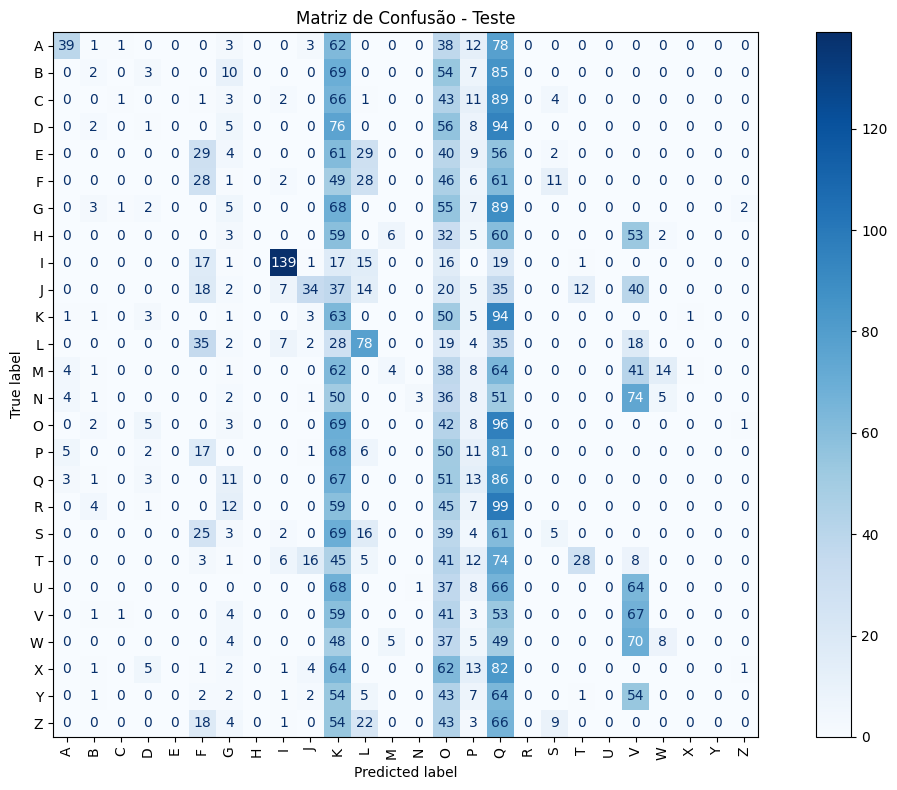

              precision    recall  f1-score   support

           A       0.70      0.16      0.27       237
           B       0.10      0.01      0.02       230
           C       0.25      0.00      0.01       221
           D       0.04      0.00      0.01       242
           E       0.00      0.00      0.00       230
           F       0.14      0.12      0.13       232
           G       0.06      0.02      0.03       232
           H       0.00      0.00      0.00       220
           I       0.83      0.62      0.71       226
           J       0.51      0.15      0.23       224
           K       0.04      0.28      0.07       222
           L       0.36      0.34      0.35       228
           M       0.27      0.02      0.03       238
           N       0.75      0.01      0.03       235
           O       0.04      0.19      0.06       226
           P       0.06      0.05      0.05       241
           Q       0.05      0.37      0.09       235
           R       0.00    

In [14]:
from sklearn.metrics import accuracy_score

y_test_pred = best_model.predict(X_test_hv_1)

final_test_acc = accuracy_score(y_test_pred.cpu(), torch.tensor(y_test).cpu())
print("Melhor acurácia no treino:", best_acc)
print("Melhores parâmetros:", best_params)
print("Acurácia final no teste:", final_test_acc)


y_test_np = torch.tensor(y_test).cpu().numpy()
y_test_pred_np = y_test_pred.cpu().numpy()

plot_confusion_matrix(y_test_np, y_test_pred_np, le_y, maior=True, title="Matriz de Confusão - Teste")
classification_metrics(y_test_np, y_test_pred_np, le_y)



### Ngram Encoder

In [15]:
with torch.no_grad():
    X_train_tensor_2 = torch.tensor(X_train_df.values, dtype=torch.float32).to(device)
    X_test_tensor_2 = torch.tensor(X_test_df.values, dtype=torch.float32).to(device)

    X_train_hv_2 = MAPTensor(encoder_2(X_train_tensor_2)).float()
    X_test_hv_2 = MAPTensor(encoder_2(X_test_tensor_2)).float()


best_model, best_params, best_acc = NeuralHD.grid_search_encoded(
    X_train_hv=X_train_hv_2,
    y_train=torch.tensor(y_train, dtype=torch.long).to(device),
    n_features=X_train_df.shape[1],
    n_classes=len(np.unique(y_train)),
    device=device,
    param_grid=param_grid,
    max_trials=20
)

fit: 100%|██████████| 29/29 [01:04<00:00,  2.21s/it]


[ACC=0.0539] dim=15000, levels=10, rate=0.01, freq=10, epochs=30, lr=0.1


fit: 100%|██████████| 19/19 [00:42<00:00,  2.25s/it]


[ACC=0.0482] dim=15000, levels=10, rate=0.01, freq=20, epochs=20, lr=0.1


fit: 100%|██████████| 29/29 [01:04<00:00,  2.22s/it]


...

[ACC=0.0647] dim=15000, levels=10, rate=0.01, freq=10, epochs=40, lr=0.1


fit: 100%|██████████| 19/19 [00:42<00:00,  2.22s/it]


[ACC=0.0475] dim=15000, levels=25, rate=0.05, freq=20, epochs=20, lr=0.2


fit: 100%|██████████| 39/39 [01:26<00:00,  2.23s/it]


[ACC=0.0647] dim=15000, levels=25, rate=0.02, freq=10, epochs=40, lr=0.1


Melhor acurácia no treino: 0.06471428571428571
Melhores parâmetros: {'dimension': 15000, 'num_levels': 10, 'regen_rate': 0.05, 'regen_freq': 20, 'epochs': 40, 'lr': 0.1}
Acurácia final no teste: 0.06466666666666666


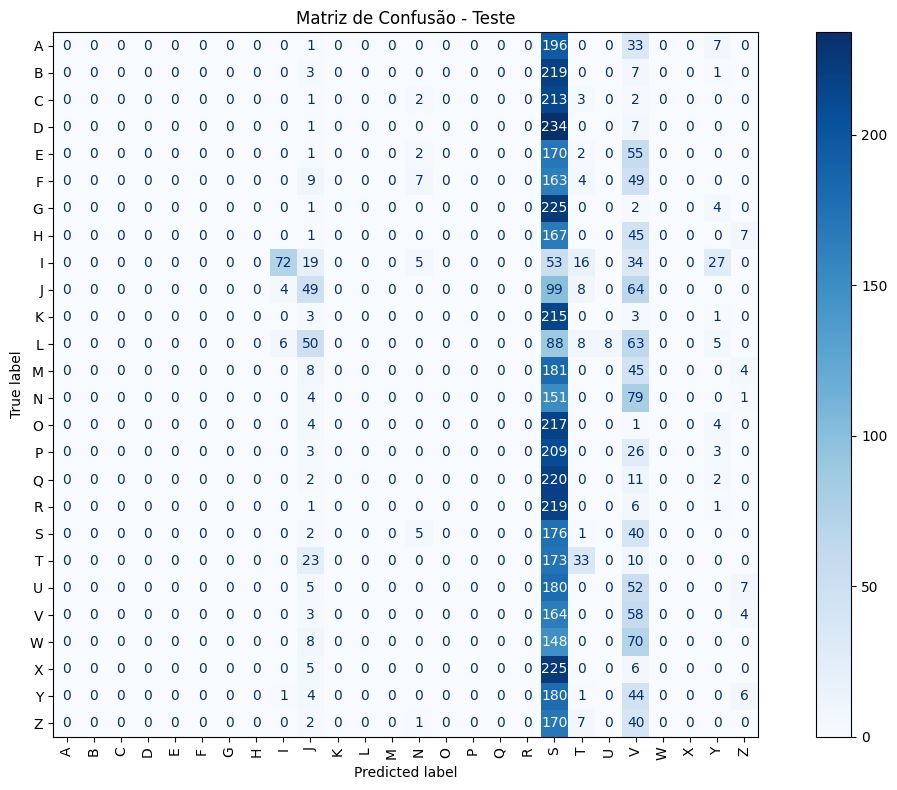

              precision    recall  f1-score   support

           A       0.00      0.00      0.00       237
           B       0.00      0.00      0.00       230
           C       0.00      0.00      0.00       221
           D       0.00      0.00      0.00       242
           E       0.00      0.00      0.00       230
           F       0.00      0.00      0.00       232
           G       0.00      0.00      0.00       232
           H       0.00      0.00      0.00       220
           I       0.87      0.32      0.47       226
           J       0.23      0.22      0.22       224
           K       0.00      0.00      0.00       222
           L       0.00      0.00      0.00       228
           M       0.00      0.00      0.00       238
           N       0.00      0.00      0.00       235
           O       0.00      0.00      0.00       226
           P       0.00      0.00      0.00       241
           Q       0.00      0.00      0.00       235
           R       0.00    

In [16]:
from sklearn.metrics import accuracy_score

print("Melhor acurácia no treino:", best_acc)
print("Melhores parâmetros:", best_params)

y_test_pred = best_model.predict(X_test_hv_2)
final_test_acc = accuracy_score(y_test_pred.cpu(), torch.tensor(y_test).cpu())
print("Acurácia final no teste:", final_test_acc)

y_test_np = torch.tensor(y_test).cpu().numpy()
y_test_pred_np = y_test_pred.cpu().numpy()

plot_confusion_matrix(y_test_np, y_test_pred_np, le_y, maior=True, title="Matriz de Confusão - Teste")
classification_metrics(y_test_np, y_test_pred_np, le_y)
